### Datos de distintas estaciones meteorológicas de Australia. [https://www.kaggle.com/jsphyg/weather-dataset-rattle-package?select=weatherAUS.csv]

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import auc, roc_curve ,  RocCurveDisplay
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.impute import KNNImputer
from sklearn.linear_model import LinearRegression
from tqdm import tqdm
from scipy import stats
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.preprocessing import LabelEncoder

from torch.utils.data import DataLoader, TensorDataset

### Visualizacion de las primeras filas.


In [ ]:
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
dataset = pd.read_csv("weatherAUS.csv") # cargando los datos desde un CSV
dataset.head(5)

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,WNW,20.0,24.0,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,WSW,4.0,22.0,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,WSW,19.0,26.0,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,E,11.0,9.0,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,NW,7.0,20.0,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No


### Informacion general

In [ ]:
### Nuestra variable de salida sera: RainTomorrow

In [ ]:
dataset.describe()
# Este analisis inicial, nos permite destacar una feature, Rainfall. La cual a pesar de sus primeros tres cuartiles ser 0 o muy cerca,
# tiene valores máximos como 371 alejando se mucho de su media. Esto puede tener sentidos en un clima como australia , muy seco y pocos periodos
# Lluviosos.

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm
count,143975.000000,144199.000000,142199.000000,82670.000000,75625.000000,135197.000000,143693.000000,142398.000000,142806.000000,140953.000000,130395.00000,130432.000000,89572.000000,86102.000000,143693.000000,141851.00000
mean,12.194034,23.221348,2.360918,5.468232,7.611178,40.035230,14.043426,18.662657,68.880831,51.539116,1017.64994,1015.255889,4.447461,4.509930,16.990631,21.68339
std,6.398495,7.119049,8.478060,4.193704,3.785483,13.607062,8.915375,8.809800,19.029164,20.795902,7.10653,7.037414,2.887159,2.720357,6.488753,6.93665
min,-8.500000,-4.800000,0.000000,0.000000,0.000000,6.000000,0.000000,0.000000,0.000000,0.000000,980.50000,977.100000,0.000000,0.000000,-7.200000,-5.40000
25%,7.600000,17.900000,0.000000,2.600000,4.800000,31.000000,7.000000,13.000000,57.000000,37.000000,1012.90000,1010.400000,1.000000,2.000000,12.300000,16.60000
50%,12.000000,22.600000,0.000000,4.800000,8.400000,39.000000,13.000000,19.000000,70.000000,52.000000,1017.60000,1015.200000,5.000000,5.000000,16.700000,21.10000
75%,16.900000,28.200000,0.800000,7.400000,10.600000,48.000000,19.000000,24.000000,83.000000,66.000000,1022.40000,1020.000000,7.000000,7.000000,21.600000,26.40000
max,33.900000,48.100000,371.000000,145.000000,14.500000,135.000000,130.000000,87.000000,100.000000,100.000000,1041.00000,1039.600000,9.000000,9.000000,40.200000,46.70000


### Identificar los tipos de datos: categórico, ordinal, etc.

In [ ]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           145460 non-null  object 
 1   Location       145460 non-null  object 
 2   MinTemp        143975 non-null  float64
 3   MaxTemp        144199 non-null  float64
 4   Rainfall       142199 non-null  float64
 5   Evaporation    82670 non-null   float64
 6   Sunshine       75625 non-null   float64
 7   WindGustDir    135134 non-null  object 
 8   WindGustSpeed  135197 non-null  float64
 9   WindDir9am     134894 non-null  object 
 10  WindDir3pm     141232 non-null  object 
 11  WindSpeed9am   143693 non-null  float64
 12  WindSpeed3pm   142398 non-null  float64
 13  Humidity9am    142806 non-null  float64
 14  Humidity3pm    140953 non-null  float64
 15  Pressure9am    130395 non-null  float64
 16  Pressure3pm    130432 non-null  float64
 17  Cloud9am       89572 non-null

In [ ]:
# Listado de Columnas Númericas:
columns_numericas=dataset.select_dtypes(include=['float64', 'int64']).columns.tolist()
print(columns_numericas)

['MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine', 'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am', 'Temp3pm']


16it [00:29,  1.84s/it]


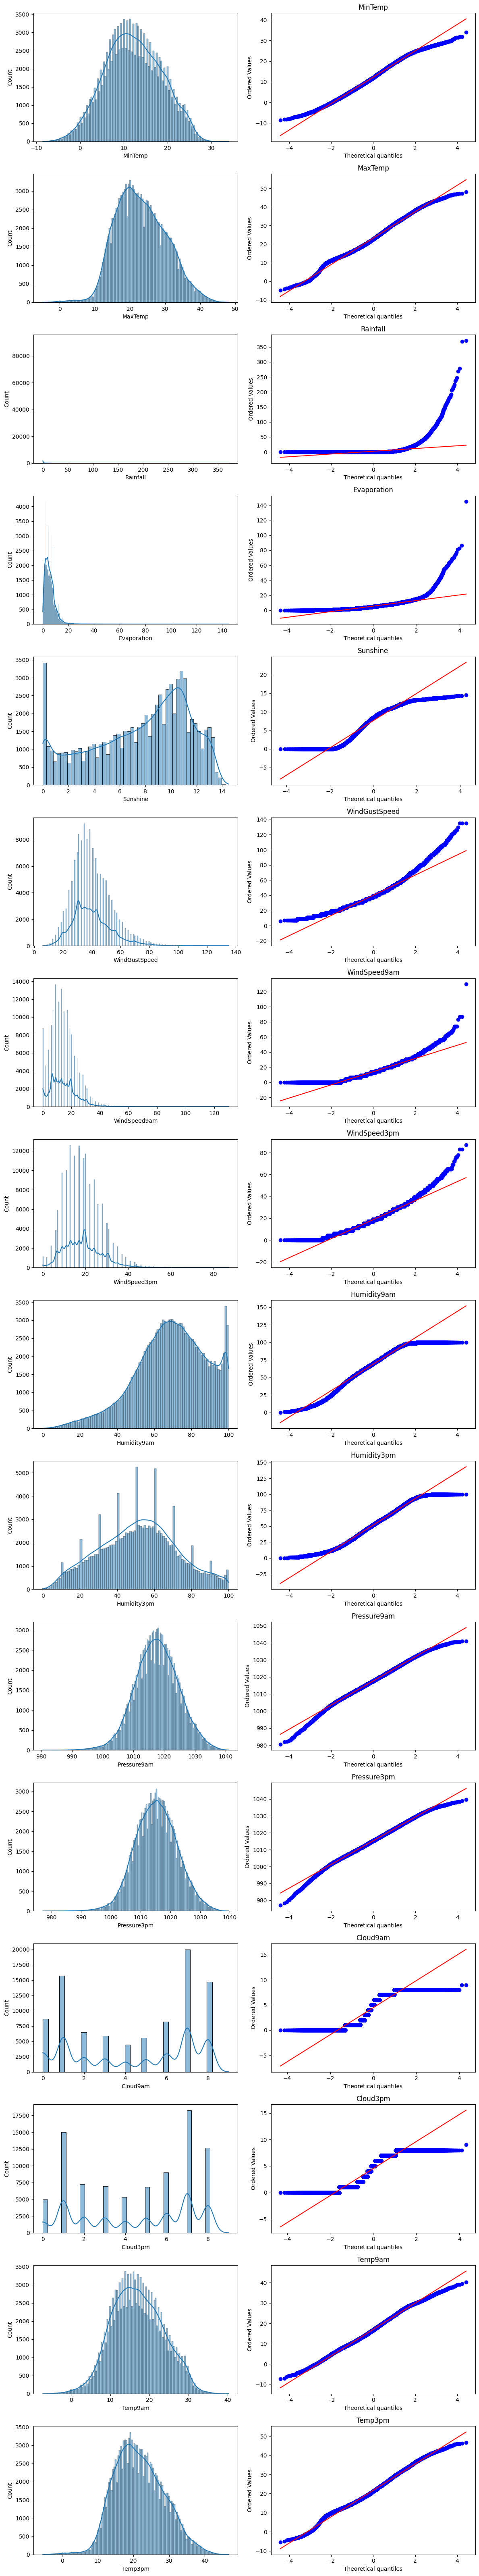

In [ ]:
def distribuciones(dataset, columnas):

    fig, axes = plt.subplots(len(columnas), 2, figsize=(12, len(columnas)*4))

    for i, col in tqdm(enumerate(columnas)):
        sns.histplot(dataset[col], ax = axes[i, 0], kde =True)
        stats.probplot(dataset[col].dropna(), dist='norm', plot=axes[i, 1])
        axes[i, 1].set_title(col)

    plt.tight_layout()
    plt.show()

distribuciones(dataset, columns_numericas)
# Los features MinTemp, MaxTemp, Preassure9am , Preassure3pm, Temp9am, Temp3pm se distribuyen como normales
# Para Rainfall si bien la mayoria de sus valores tienden a 0, tiene outliers que se alejan mucho de su media.
# Para Evaporation, se ve tiende a una normal a la izquierda, tiene outliers que se alejan un tanto de su media.
# Para Sunshine, parece seguir una distribucion bivariada.
# Para WindGustSpeed, WindSpeed9am, WindSpeed3pm, tienden a centrar sus datos como normal, pero con outliers que dispersan la distribución.
# Para Humedity9am, Humedity3pm, tienden a una normal
# Para Could9pm, Could3pm, no queda clara la distribución de los datos

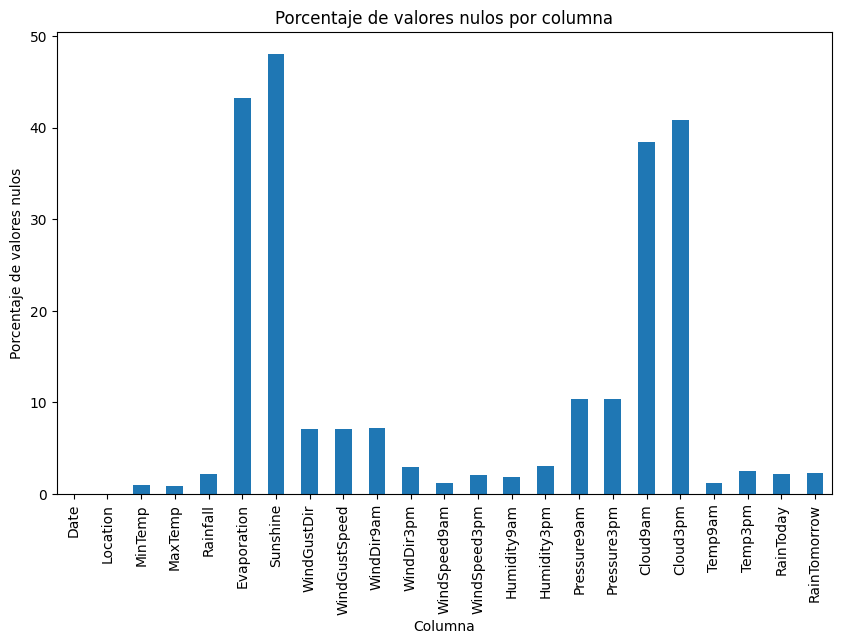

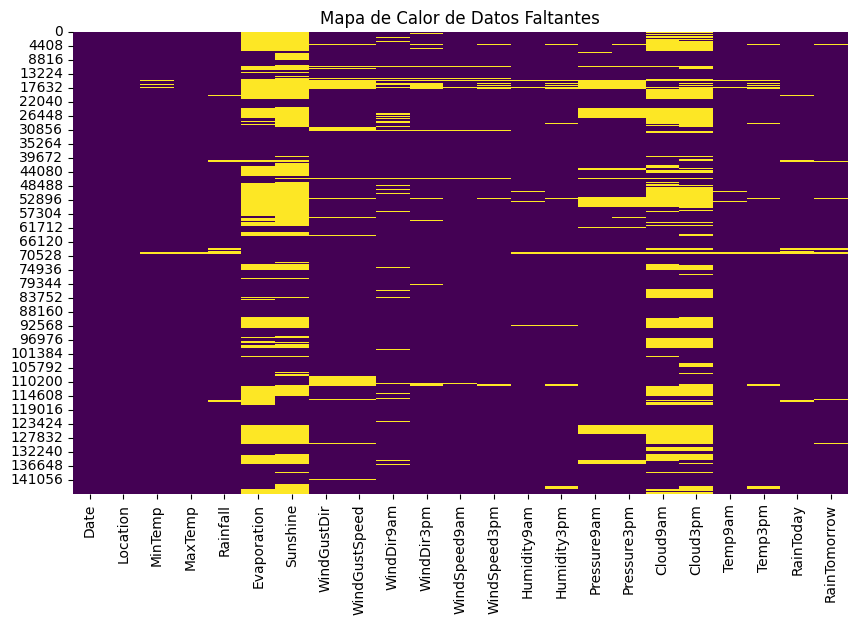

In [ ]:
# Buscamos columnas porcenrtaje de valores nulos por columna

def nan_values(dataset):

    nan_percentage = (dataset.isnull().mean() * 100).round(2)
    nan_percentage.plot(kind='bar', figsize=(10, 6))
    plt.title('Porcentaje de valores nulos por columna')
    plt.xlabel('Columna')
    plt.ylabel('Porcentaje de valores nulos')
    plt.show()

    plt.figure(figsize=(10, 6))
    sns.heatmap(dataset.isnull(), cbar=False, cmap='viridis')
    plt.title('Mapa de Calor de Datos Faltantes')
    plt.show()

nan_values(dataset)
# Se ve que, la columna target tiene valores nulos, con lo cual se borraran esos registros.
dataset = dataset.dropna(subset=['RainTomorrow'])
# Se buscaras completar los valores nulos de otras columnas, casos especiales para Evaporation, Sunshine, Cloud9am, Cloud3pm; con un alto
# porcentaje de valores nulos con respecto al dataset

# Analizando el mapa de calor, se ve alguna relación en la ausencia de datos entre Evaporation y Sunshine, suele haber ausencia de los mismos en momentos similares y la cantidad de datos faltantes es aproximada
# Lo mismo ocurre con Cloud9am y Cloud3pm. Lo cual nos lleva  a pensar o suponer que los mecanismos de mediciones eran los mismos y al fallar hay ausencia de ambos datos

In [ ]:
# Convirtiendo columnas categóricas a numéricas
dataset['RainToday'] = dataset['RainToday'].apply(lambda x: 1 if x == 'Yes' else 0)
dataset['RainToday'] = dataset['RainToday'].astype('float64')
dataset['RainTomorrow'] = dataset['RainTomorrow'].apply(lambda x: 1 if x == 'Yes' else 0)
dataset['RainTomorrow'] = dataset['RainTomorrow'].astype('float64')

label_encoder = LabelEncoder()
dataset['WindGustDir'] = label_encoder.fit_transform(dataset['WindGustDir'])
dataset['WindDir9am'] = label_encoder.fit_transform(dataset['WindDir9am'])
dataset['WindDir3pm'] = label_encoder.fit_transform(dataset['WindDir3pm'])
dataset['Location'] = label_encoder.fit_transform(dataset['Location'])
dataset_inicial = dataset.copy()

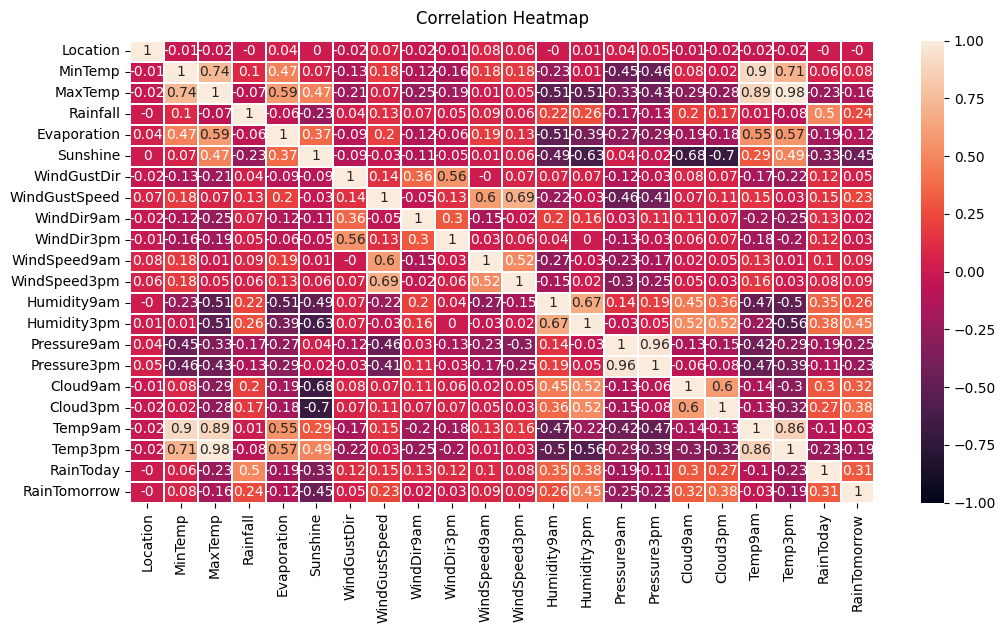

In [ ]:
df_numeric = dataset.select_dtypes(exclude=['object'])
plt.figure(figsize=(12, 6))
heatmap = sns.heatmap(df_numeric.corr().round(2), vmin=-1, vmax=1, annot=True, linewidth=.01);
heatmap.set_title('Correlation Heatmap', fontdict={'fontsize':12}, pad=12);

/usr/local/lib/python3.10/dist-packages/sklearn/impute/_iterative.py:785: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


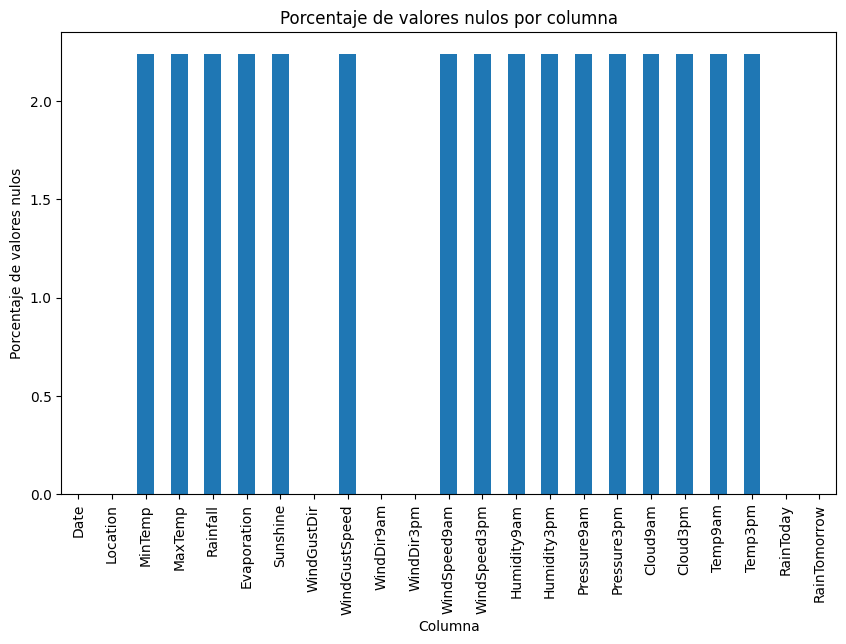

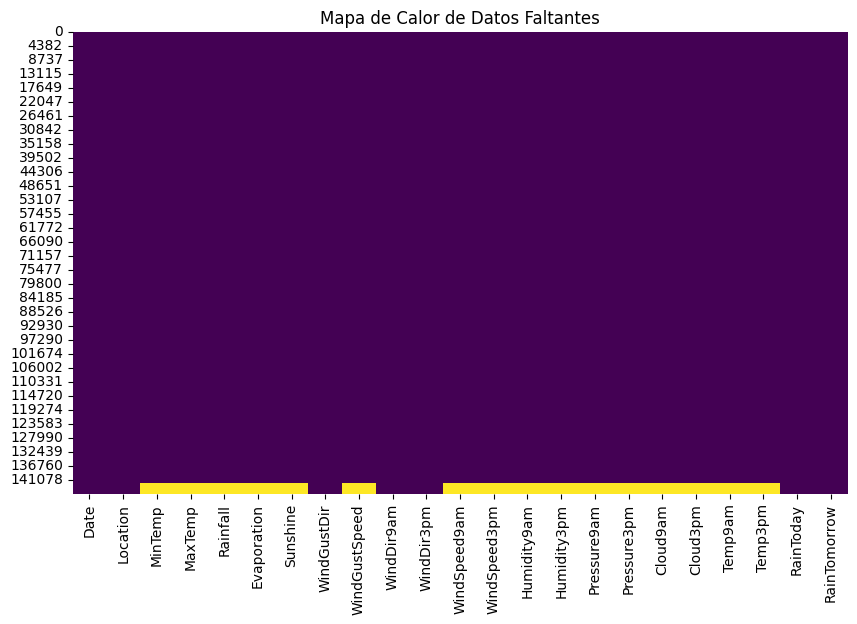

In [ ]:
columns_with_nan = dataset.columns[dataset.isnull().any()].tolist()

data = dataset[columns_with_nan]

imputer = IterativeImputer(random_state=0, min_value=0)
#SE decide poner min_value=0, dado que se noto que estaba generando valores negativos para columnas que no tiene sentido.
# La unica que puese tener negativos es MinTemp,Temp9am, Temp3pm pero sus faltantes son tan pocos que no se considera afecte esta restriccion
imputed_data = imputer.fit_transform(data)

imputed_df = pd.DataFrame(imputed_data, columns=data.columns)

dataset[columns_with_nan] = imputed_df
nan_values(dataset)
#Notamos que el algoritmo, no fue capaz de llenar todos las columnas, esto fue esperado pues, se sabe que el algoritmo no trabaja bien en casos
# donde hay muchas columnas con valores faltantes al mismo tiempo

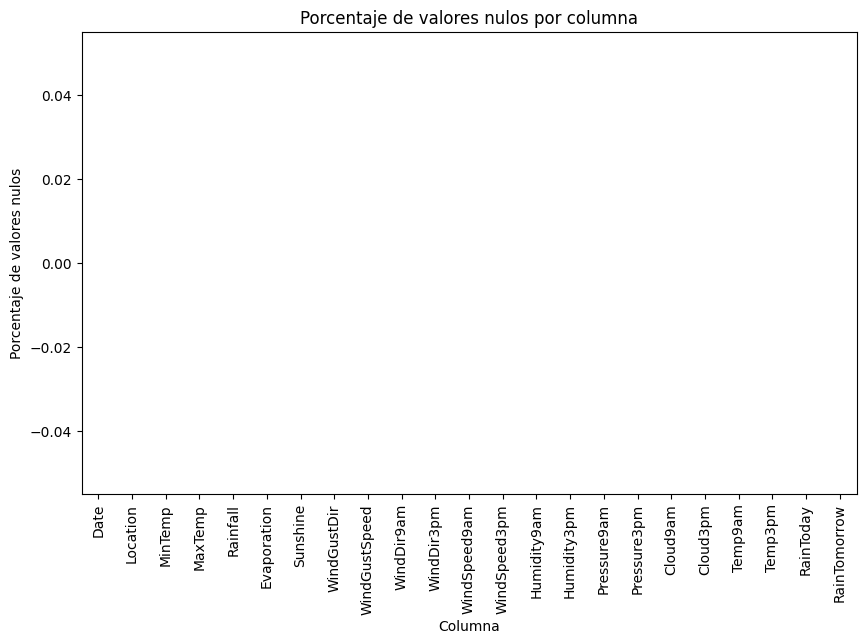

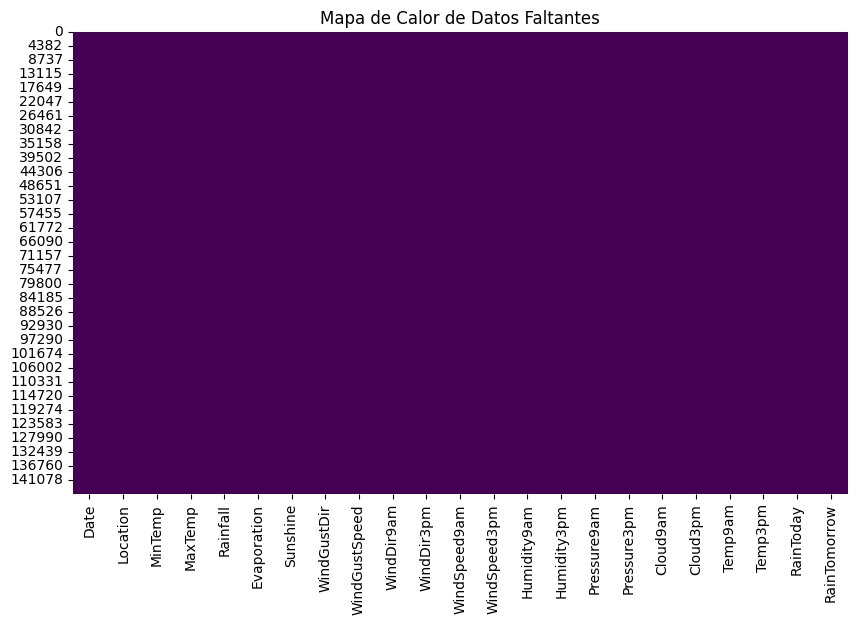

In [ ]:
# Intentaremos rellenar los faltantes con KNNImputer, otra opcion puede ser eliminarlos ya que no representan mas del 2% del data set

columns_with_nan = dataset.columns[dataset.isnull().any()].tolist()


# Imputación de valores faltantes utilizando KNNImputer
imputer = KNNImputer(n_neighbors=5)
dataset[columns_with_nan] = imputer.fit_transform(dataset[columns_with_nan])

nan_values(dataset)

In [ ]:
# Se realizan los estadísticos generales para validar si la data generada afecto en alta medida alguno
dataset.describe()

,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
count,142193.000000,142193.000000,142193.000000,142193.000000,142193.000000,142193.000000,142193.000000,142193.000000,142193.000000,142193.000000,142193.000000,142193.000000,142193.000000,142193.000000,142193.000000,142193.000000,142193.000000,142193.000000,142193.000000,142193.00000,142193.000000,142193.000000
mean,23.740655,12.203940,23.233668,2.361809,5.105012,7.427279,8.255885,39.740433,7.915755,7.974471,13.983848,18.633173,68.933357,51.603938,1017.721057,1015.322529,4.380390,4.485857,16.980494,21.72330,0.221213,0.224181
std,14.237503,6.329501,7.025808,8.341740,3.602252,3.425641,4.953096,13.328238,4.911307,4.731493,8.765192,8.656355,18.800147,20.465275,6.710819,6.651543,2.516821,2.334367,6.435295,6.88627,0.415065,0.417043
min,0.000000,-8.500000,-4.800000,0.000000,0.000000,0.000000,0.000000,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,980.500000,977.100000,0.000000,0.000000,-7.200000,-5.40000,0.000000,0.000000
25%,11.000000,7.700000,18.000000,0.000000,2.665257,5.039243,4.000000,31.000000,3.000000,4.000000,7.000000,13.000000,57.000000,37.000000,1013.600000,1011.100000,2.000000,2.733599,12.400000,16.70000,0.000000,0.000000
50%,24.000000,12.200000,22.900000,0.000000,4.747909,7.615215,9.000000,39.000000,8.000000,8.000000,13.000000,18.633173,69.000000,51.603938,1017.721057,1015.322529,4.451911,4.491457,16.900000,21.40000,0.000000,0.000000
75%,36.000000,16.700000,28.100000,1.000000,6.800000,10.100000,13.000000,46.000000,12.000000,12.000000,19.000000,24.000000,83.000000,65.000000,1021.800000,1019.400000,7.000000,6.751596,21.400000,26.30000,0.000000,0.000000
max,48.000000,33.900000,48.100000,371.000000,86.200000,17.275215,16.000000,137.597868,16.000000,16.000000,130.000000,87.000000,113.819017,100.000000,1041.000000,1039.600000,10.588755,12.153836,40.200000,46.70000,1.000000,1.000000


In [ ]:
dataset_inicial.describe()

,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
count,142193.000000,141556.000000,141871.000000,140787.000000,81350.000000,74377.000000,142193.000000,132923.000000,142193.000000,142193.000000,140845.000000,139563.000000,140419.000000,138583.000000,128179.000000,128212.000000,88536.000000,85099.000000,141289.000000,139467.000000,142193.000000,142193.000000
mean,23.740655,12.186400,23.226784,2.349974,5.469824,7.624853,8.255885,39.984292,7.915755,7.974471,14.001988,18.637576,68.843810,51.482606,1017.653758,1015.258204,4.437189,4.503167,16.987509,21.687235,0.221213,0.224181
std,14.237503,6.403283,7.117618,8.465173,4.188537,3.781525,4.953096,13.588801,4.911307,4.731493,8.893337,8.803345,19.051293,20.797772,7.105476,7.036677,2.887016,2.720633,6.492838,6.937594,0.415065,0.417043
min,0.000000,-8.500000,-4.800000,0.000000,0.000000,0.000000,0.000000,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,980.500000,977.100000,0.000000,0.000000,-7.200000,-5.400000,0.000000,0.000000
25%,11.000000,7.600000,17.900000,0.000000,2.600000,4.900000,4.000000,31.000000,3.000000,4.000000,7.000000,13.000000,57.000000,37.000000,1012.900000,1010.400000,1.000000,2.000000,12.300000,16.600000,0.000000,0.000000
50%,24.000000,12.000000,22.600000,0.000000,4.800000,8.500000,9.000000,39.000000,8.000000,8.000000,13.000000,19.000000,70.000000,52.000000,1017.600000,1015.200000,5.000000,5.000000,16.700000,21.100000,0.000000,0.000000
75%,36.000000,16.800000,28.200000,0.800000,7.400000,10.600000,13.000000,48.000000,12.000000,12.000000,19.000000,24.000000,83.000000,66.000000,1022.400000,1020.000000,7.000000,7.000000,21.600000,26.400000,0.000000,0.000000
max,48.000000,33.900000,48.100000,371.000000,145.000000,14.500000,16.000000,135.000000,16.000000,16.000000,130.000000,87.000000,100.000000,100.000000,1041.000000,1039.600000,9.000000,9.000000,40.200000,46.700000,1.000000,1.000000


In [ ]:
# Si bien, si se ve algunos cambios, los mismos no parecen ser muy relevantes.

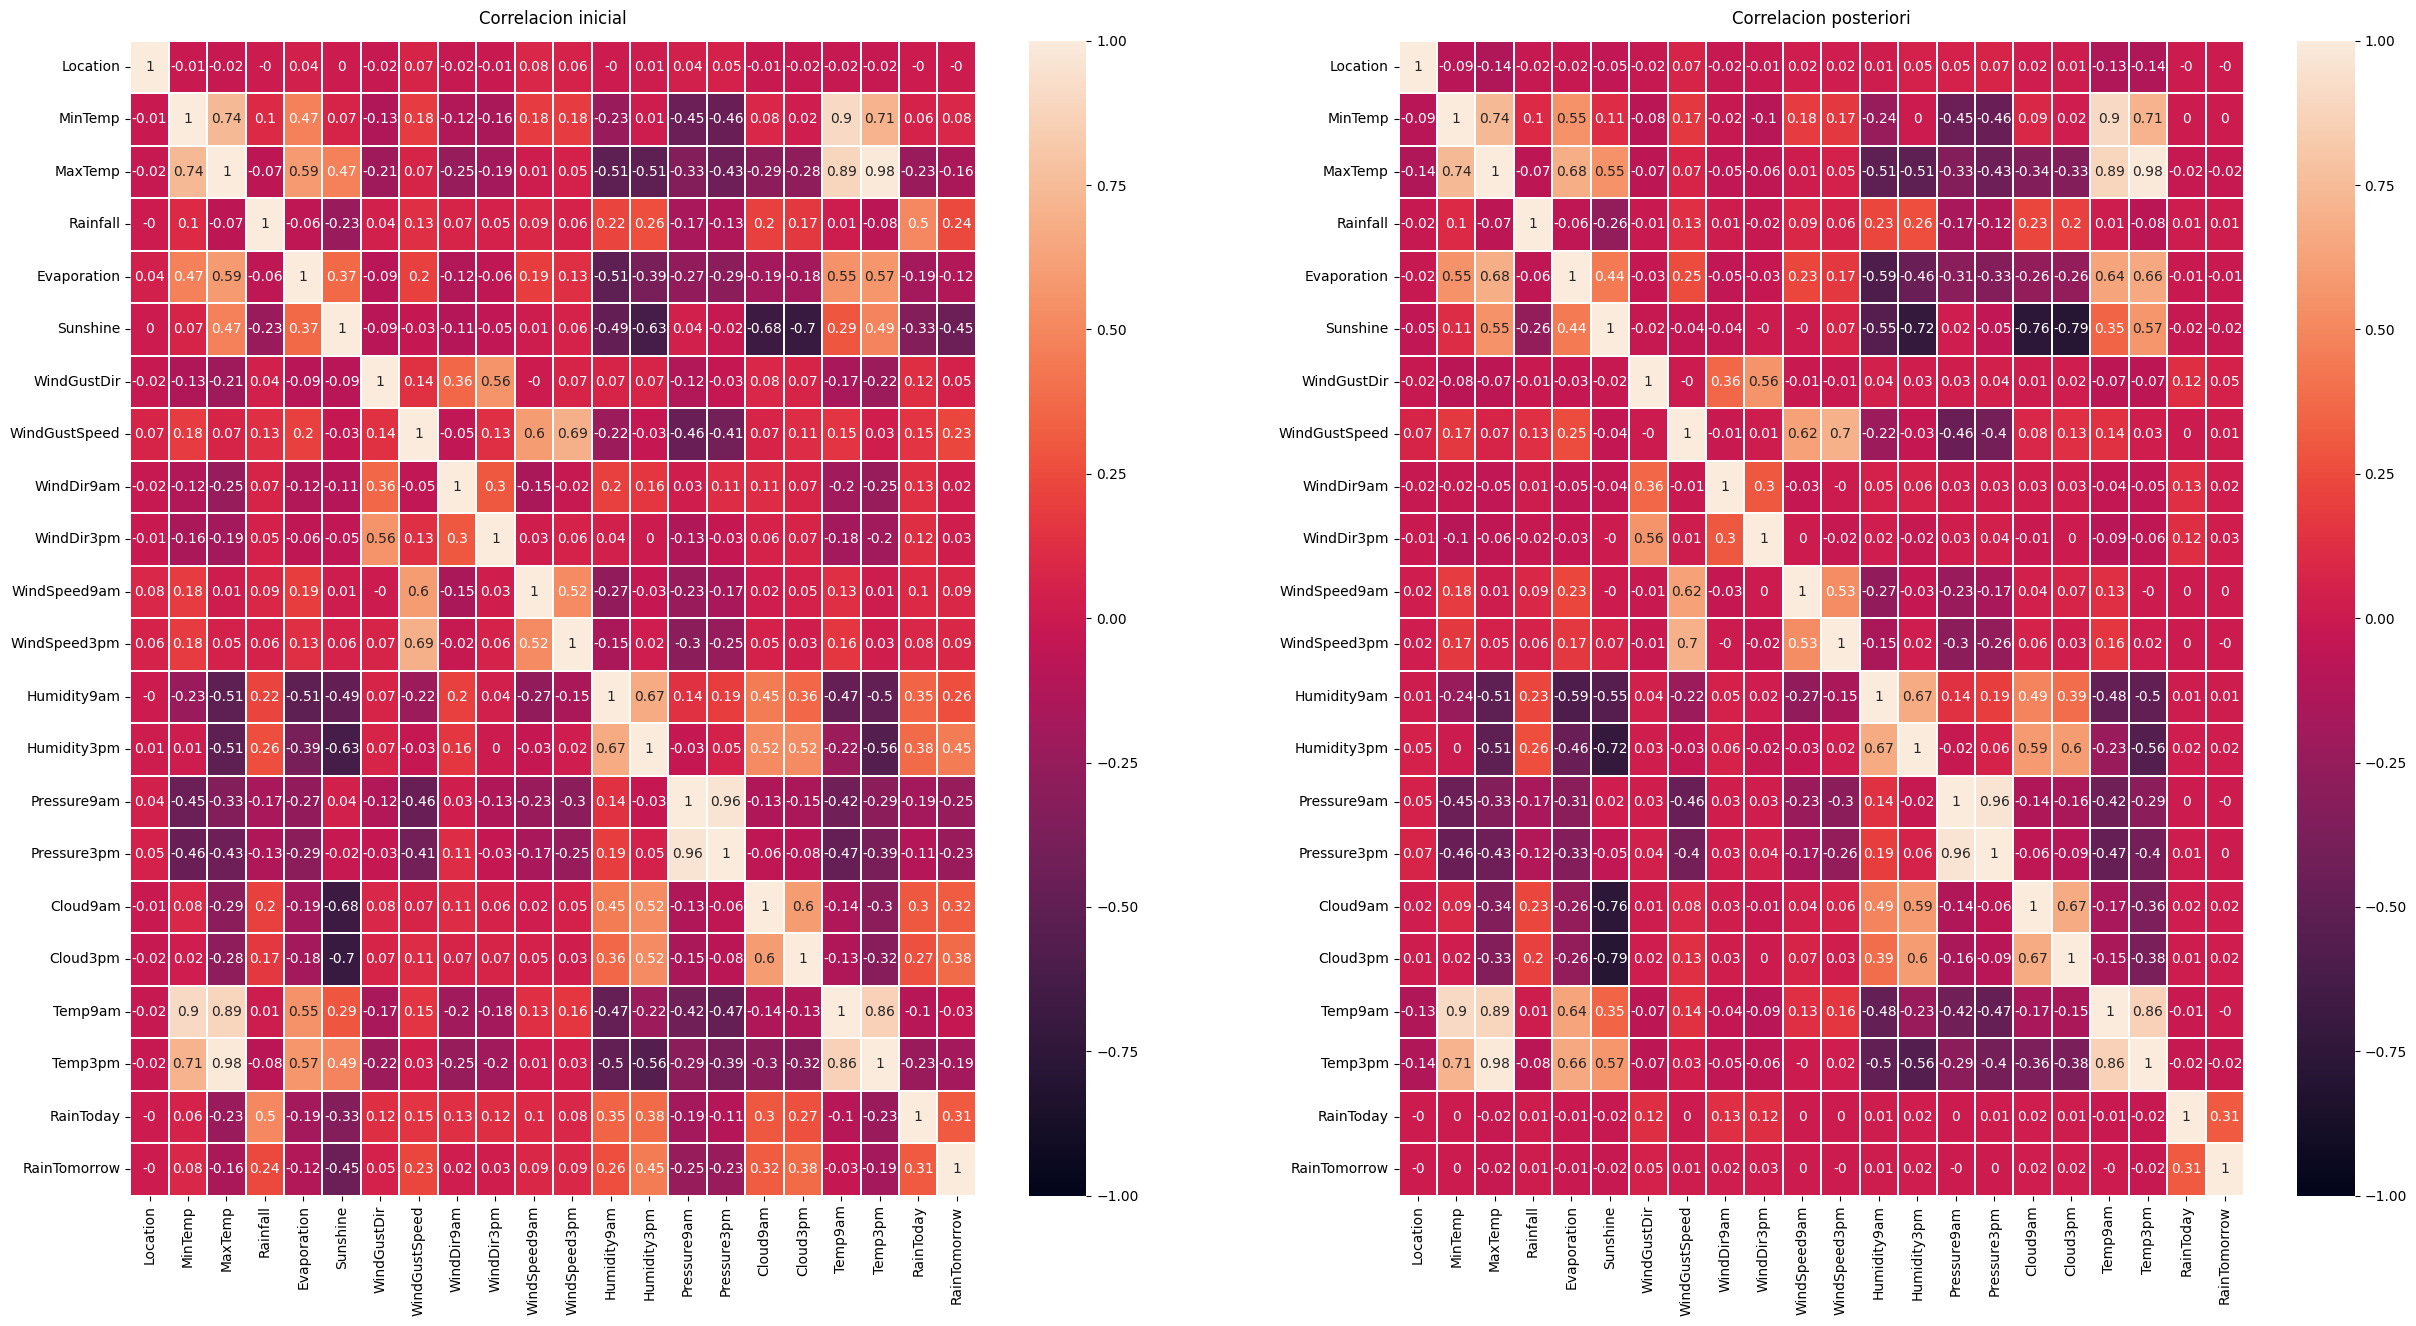

<Figure size 1200x600 with 0 Axes>

<Figure size 1200x600 with 0 Axes>

In [ ]:
def correlation(_dataset):
    df_numeric = _dataset.select_dtypes(exclude=['object'])
    plt.figure(figsize=(12, 6))
    return df_numeric.corr().round(2)

#Ahora validaremos si, los nuevos datos afectaron enormemente la correlacion de las variables

fig, ax = plt.subplots(1, 2, figsize=(30, 15))

sns.heatmap(correlation(dataset_inicial), vmin=-1, vmax=1, annot=True, linewidth=.01, ax=ax[0])
ax[0].set_title('Correlacion inicial', fontdict={'fontsize':12}, pad=12)

sns.heatmap(correlation(dataset), vmin=-1, vmax=1, annot=True, linewidth=.01, ax=ax[1])
ax[1].set_title('Correlacion posteriori', fontdict={'fontsize':12}, pad=12)

plt.show()
#No se ve una afectacion en las correlaciones con los datos nuevo

16it [00:29,  1.84s/it]


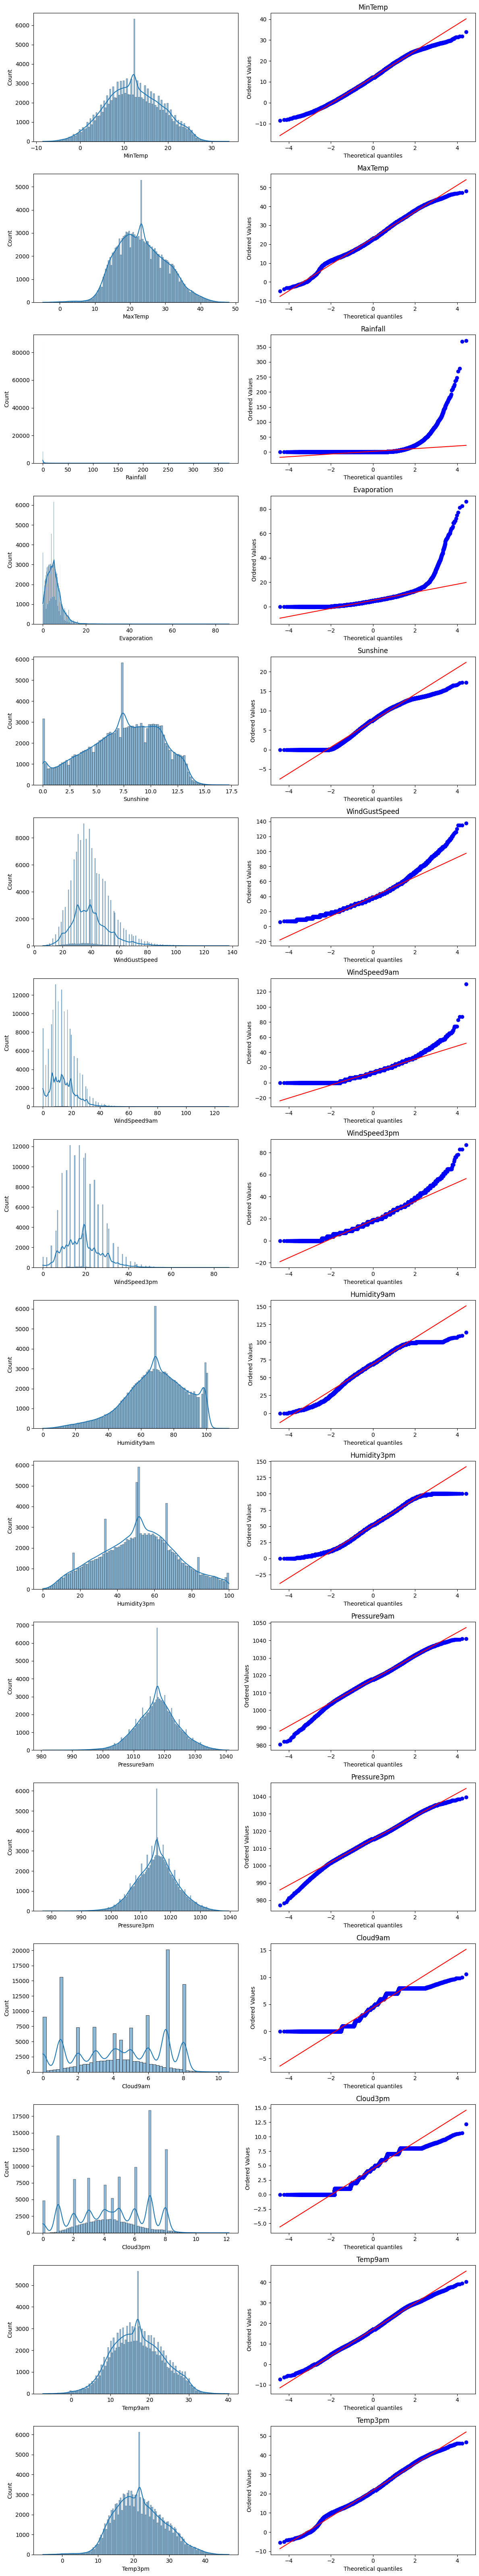

In [ ]:
distribuciones(dataset, columns_numericas)

In [ ]:
# Al revisar nuevamente las distribuciones, si bien se ven cambios en los mismos, no se ve que hallan afectado la tendencia de los datos

## Predicción utilizando Regresión Logística Múltiple

In [ ]:
##########################################################################
# Conversión de la fecha para columnas separadas para entrenamiento
##########################################################################

# 1 - Convertir Fecha para datetime así podemos utilizar para el entrenamiento:
dataset['Date'] = pd.to_datetime(dataset['Date'])
# Separar año, mes, día de la columna
dataset['Year'] = dataset['Date'].dt.year
dataset['Month'] = dataset['Date'].dt.month
dataset['Day'] = dataset['Date'].dt.day

#Despues borramos la columns date:
dataset = dataset.drop('Date', axis=1)

#Guardamos una copia, para el modelo de red neuronal
dataset_copia=dataset

In [ ]:
#empezando con la separación de los atributos y el target:
y = dataset.loc[:, ["RainTomorrow"]].values
dataset = dataset.drop('RainTomorrow', axis=1)
X = dataset.loc[:, :].values

In [ ]:
#Primer hago la misma division incluyendo RainTomorrow para hace comparaciones de datos despues
C_train, C_test, w_train, w_test = train_test_split(dataset_copia, y, test_size = 0.3, random_state = 42, stratify=y)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 42, stratify=y)

In [ ]:
sc_X = StandardScaler()
X_train = sc_X.fit_transform(X_train)
X_test = sc_X.transform(X_test)

In [ ]:
# Entrenamos el modelo por máxima verosimilitud
classifier_log = LogisticRegression(random_state = 0, class_weight="balanced")
classifier_log.fit(X_train, y_train)

/usr/local/lib/python3.10/dist-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


LogisticRegression(class_weight='balanced', random_state=0)

In [ ]:
print(f"Porcentaje de muestras bien clasificadas usando todos los atributos: {(classifier_log.score(X_test, y_test)*100)}%")

Porcentaje de muestras bien clasificadas usando todos los atributos: 75.9060434150687%


In [ ]:
# Necesitamos entender el modelo:
y_pred_test = classifier_log.predict(X_test)

In [ ]:
cm_balanced = confusion_matrix(y_test, y_pred_test)

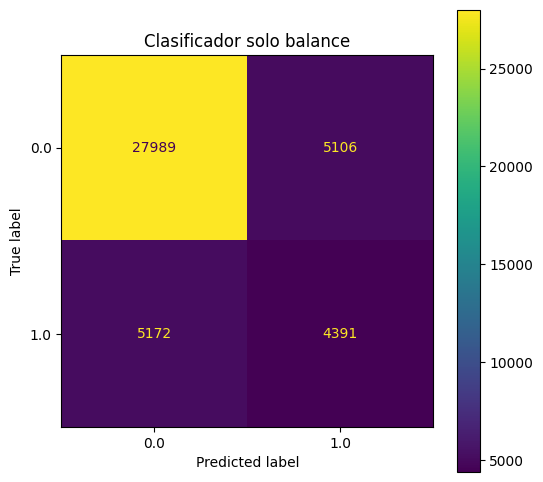

In [ ]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm_balanced,
                              display_labels=classifier_log.classes_)

fig, ax = plt.subplots(figsize=(6,6))
ax.grid(False)
disp.plot(ax=ax)
ax.set_title("Clasificador solo balance");

In [ ]:
# Calculamos F1-score
f1 = f1_score(y_test, y_pred_test)
print(f'F1-score de testeo fue: {f1:.4f}')

F1-score de testeo fue: 0.4608


### Visualizando los resultados predecidos y comparando con los datos originales como ejemplo

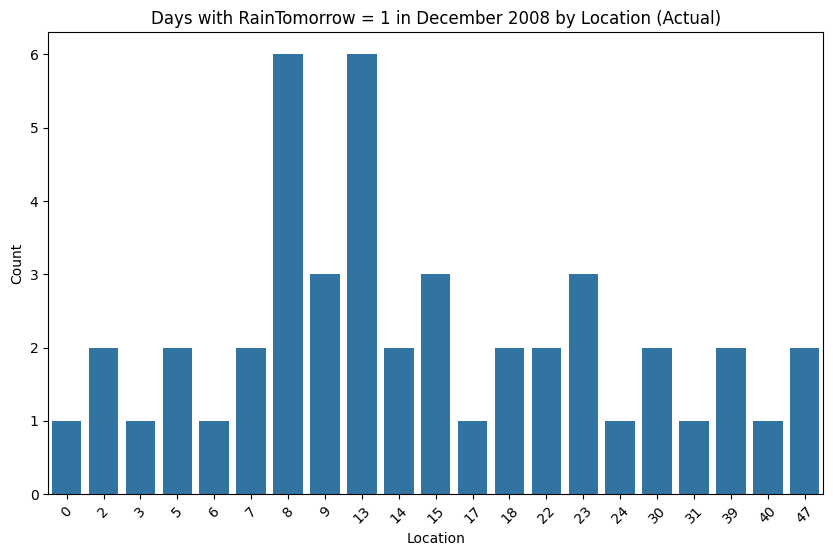

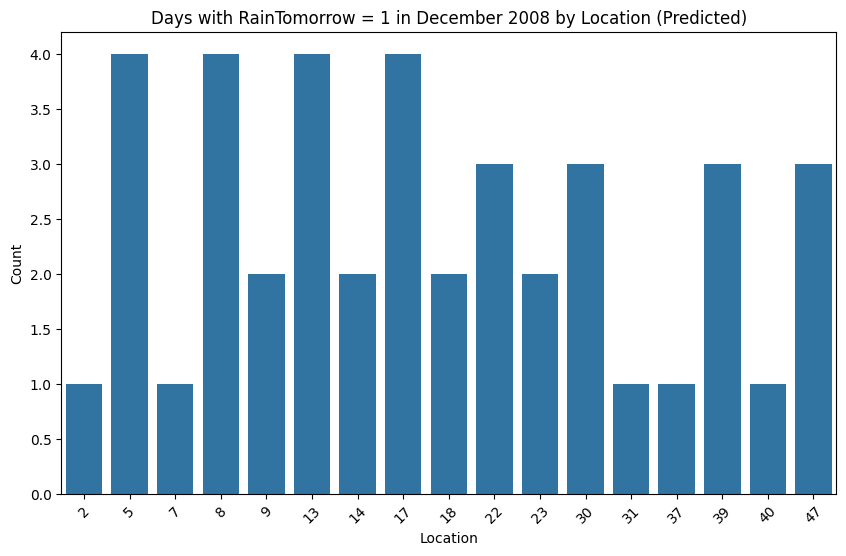

In [ ]:
# Creando un nuevo dataframe con las columnas deseadas
df = C_test[["Location", "Year", "Month", "RainTomorrow"]].copy()
df["y_pred_test"] = y_pred_test

# Filtrar el dataframe por una fecha deseada
df_filtered = df[(df["Year"] == 2008) & (df["Month"] == 12) & (df["RainTomorrow"] == 1)]

# Agrupar el dataframe filtrador por ubicación y hacer un count en del numero de días que llueve
df_grouped = df_filtered.groupby("Location").size().reset_index(name="Count")

# Sort del dataframe por count y en orden descendente
df_grouped = df_grouped.sort_values(by="Count", ascending=False)

plt.figure(figsize=(10, 6))

# Creando la barra del total de días que va llover mañana por ubicación
sns.barplot(x="Location", y="Count", data=df_grouped)

plt.title("Days with RainTomorrow = 1 in December 2008 by Location (Actual)")
plt.xlabel("Location")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

# Repetimos el mismo proceso para los valores predecidos
df_filtered = df[(df["Year"] == 2008) & (df["Month"] == 12) & (df["y_pred_test"] == 1)]
df_grouped = df_filtered.groupby("Location").size().reset_index(name="Count")
df_grouped = df_grouped.sort_values(by="Count", ascending=False)

plt.figure(figsize=(10, 6))

sns.barplot(x="Location", y="Count", data=df_grouped)

plt.title("Days with RainTomorrow = 1 in December 2008 by Location (Predicted)")
plt.xlabel("Location")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

## Predicción utilizando Red Neuronal

In [ ]:
X = dataset_copia.drop(columns=['RainTomorrow']).values
X = X.astype(float)
y = dataset_copia.iloc[:, -4].values
y = y.astype(float)

# Separamos los datos en entrenamiento y test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.1, stratify=y_train)

In [ ]:
# Convertimos en tensores
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.float32)

# Creamos usando DataLoader los sets
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)

batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size)
val_loader = DataLoader(val_dataset, batch_size=batch_size)

In [ ]:
class BinaryNetwork(torch.nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.layers = torch.nn.Sequential(
            torch.nn.BatchNorm1d(input_size),
            torch.nn.Linear(input_size, 32),
            torch.nn.ReLU(),
            torch.nn.Linear(32, 16),
            torch.nn.ReLU(),
            torch.nn.Linear(16, 1)
        )

    def forward(self, x):
        x = self.layers(x)
        return torch.sigmoid(x)  # Escalamos los valores entre 0 y 1

In [ ]:
# Luego inicialización del modelo, la función de pérdida y el optimizador
input_size = 24 # número de características
model = BinaryNetwork(input_size)

loss_fn = torch.nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-5)

In [ ]:
# Bucle de entrenamiento
epochs = 1000
train_losses = []
val_losses = []
val_accuracies = []

for epoch in range(1, epochs + 1):
    #  Entrenamiento
    model.train()  # Establecemos el modelo en modo de entrenamiento
    train_loss = 0.0
    for features, targets in train_loader:
        optimizer.zero_grad()
        outputs = model(features)
        loss = loss_fn(outputs, targets.unsqueeze(1))
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * features.size(0)
    train_loss /= len(train_loader.dataset)
    train_losses.append(train_loss)

    # Validación
    model.eval()  # Establecemos el modelo en modo de evaluación
    val_loss = 0.0
    val_preds = []
    val_targets = []
    with torch.no_grad():
        for features, targets in val_loader:
            outputs = model(features)
            loss = loss_fn(outputs, targets.unsqueeze(1))
            val_loss += loss.item() * features.size(0)
            val_preds.extend(outputs.round().squeeze().tolist())
            val_targets.extend(targets.tolist())
    val_loss /= len(val_loader.dataset)
    val_losses.append(val_loss)

    # Calculamos la precisión de la validación
    val_accuracy = accuracy_score(val_targets, val_preds)
    val_accuracies.append(val_accuracy)

    # Imprimimos las estadísticas de entrenamiento/validación
    print(f'Época: {epoch}/{epochs}, Costo de Entrenamiento: {train_loss:.4f}, '
          f'Costo de Validación: {val_loss:.4f}, Exactitud en Validación: {val_accuracy:.4f}')

Época: 1/1000, Costo de Entrenamiento: 0.7520, Costo de Validación: 0.7155, Exactitud en Validación: 0.3423
Época: 2/1000, Costo de Entrenamiento: 0.6822, Costo de Validación: 0.6512, Exactitud en Validación: 0.7192
Época: 3/1000, Costo de Entrenamiento: 0.6216, Costo de Validación: 0.5966, Exactitud en Validación: 0.7752
Época: 4/1000, Costo de Entrenamiento: 0.5760, Costo de Validación: 0.5594, Exactitud en Validación: 0.7758
Época: 5/1000, Costo de Entrenamiento: 0.5474, Costo de Validación: 0.5374, Exactitud en Validación: 0.7758
Época: 6/1000, Costo de Entrenamiento: 0.5313, Costo de Validación: 0.5258, Exactitud en Validación: 0.7758
Época: 7/1000, Costo de Entrenamiento: 0.5229, Costo de Validación: 0.5188, Exactitud en Validación: 0.7758
Época: 8/1000, Costo de Entrenamiento: 0.5172, Costo de Validación: 0.5129, Exactitud en Validación: 0.7758
Época: 9/1000, Costo de Entrenamiento: 0.5125, Costo de Validación: 0.5092, Exactitud en Validación: 0.7758
Época: 10/1000, Costo de Ent

Después de evaluar el rendimiento del modelo con diferentes configuraciones de épocas, decidimos utilizar 1000 épocas para el entrenamiento debido a la consistencia en los resultados obtenidos. Con esta configuración, el modelo alcanzó un costo de entrenamiento de 0,4765 y un costo de validación de 0,4789, con una exactitud en validación del 78,43%. Estos valores demostraron ser comparables y estables en varias ejecuciones, reflejando una capacidad robusta para generalizar a datos nuevos.


Conclusión: Los resultados muestran que el modelo de red neuronal aprendió eficazmente los patrones presentes en los datos de entrenamiento, con un costo entrenamiento y validación cercanos y bajos. La exactitud en validación del 78,43% indica una capacidad significativa del modelo para realizar predicciones precisas en nuevas instancias, superando el rendimiento aleatorio.

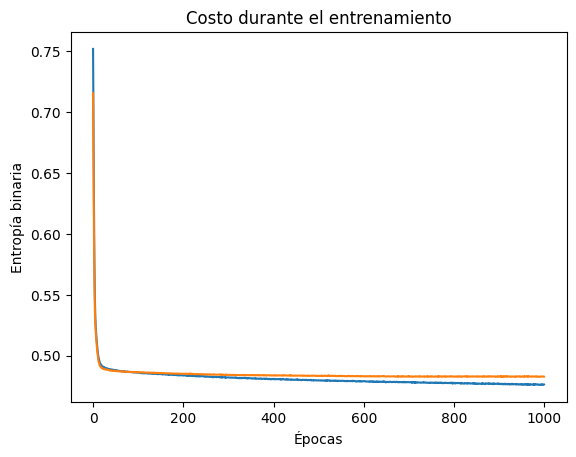

In [ ]:
# Graficamos el costo durante el entrenamiento
graph = sns.lineplot(x=[x for x in range(0, epochs)], y=train_losses)
sns.lineplot(x=[x for x in range(0, epochs)], y=val_losses)
graph.set(title="Costo durante el entrenamiento", xlabel='Épocas', ylabel='Entropía binaria')
plt.show()

In [ ]:
# Evaluamos el modelo
y_pred_list = []
y_pred_proba_list = []
model.eval()
with torch.no_grad():
    for X, y in test_loader:
        y_test_pred = model(X)
        y_pred_tag = torch.round(y_test_pred)
        y_pred_list.append(y_pred_tag)
        y_pred_proba_list.append(y_test_pred)

# Convertimos las listas a tensores
y_pred_tensor = torch.cat(y_pred_list).squeeze()
y_pred_proba_tensor = torch.cat(y_pred_proba_list).squeeze()

# Convertimos tensores a numpy arrays para métricas de evaluación
y_test_numpy = y_test_tensor.numpy()
y_pred_numpy = y_pred_tensor.numpy()
y_pred_proba_numpy = y_pred_proba_tensor.numpy()

# Calcular métricas
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

accuracy = accuracy_score(y_test_numpy, y_pred_numpy)
f1 = f1_score(y_test_numpy, y_pred_numpy)
precision = precision_score(y_test_numpy, y_pred_numpy)
recall = recall_score(y_test_numpy, y_pred_numpy)

print(f'Exactitud: {accuracy:.4f}')
print(f'F1-score: {f1:.4f}')

Exactitud: 0.7821
F1-score: 0.2838


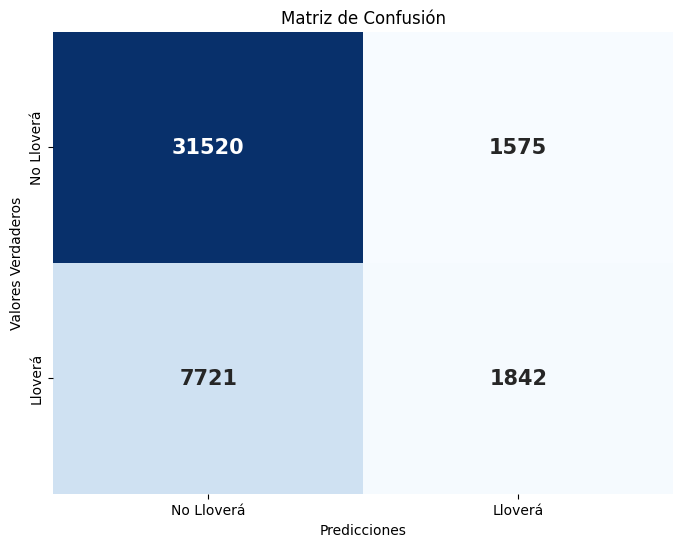

In [ ]:
# Obtenemos las predicciones y etiquetas verdaderas del conjunto de prueba
y_pred = y_pred_tensor.numpy().astype(int)  # Convertir las predicciones a numpy array
y_true = y_test_tensor.numpy().astype(int)  # Convertir las etiquetas verdaderas a numpy array

# Calculamos la matriz de confusión
cm = confusion_matrix(y_true, y_pred)

# Configuramos el gráfico de la matriz de confusión
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            annot_kws={'fontsize': 15, 'fontweight': 'bold'},
            xticklabels=['No Lloverá', 'Lloverá'],
            yticklabels=['No Lloverá', 'Lloverá'])
plt.xlabel('Predicciones')
plt.ylabel('Valores Verdaderos')
plt.title('Matriz de Confusión')
plt.show()

**Análisis Comparativo de Modelos para la Predicción de Lluvia en Australia**

Para este estudio, se crearon y evaluaron dos modelos de machine learning, un modelo de Regresión Logística y un modelo de Red Neuronal, para predecir la lluvia en diversas estaciones meteorológicas de Australia. Los resultados obtenidos fueron los siguientes:

Resultados del Modelo de Regresión Logística:
1.   Accuracy: 75.90%
2.   F1-score: 46.08%
3.   Verdaderos positivos: 27989
4.   Verdaderos negativos: 4391
5.   Falsos negativos: 5172
6.   Falsos positivos: 5106

Resultados del Modelo de Red Neuronal:
1.  Accuracy: 78.27%
2.  F1-score: 26.76%
3.  Verdaderos positivos: 31693
4.  Verdaderos negativos: 1694
5.  Falsos negativos: 7869
6.  Falsos positivos: 1402

Aunque la Red Neuronal tiene un accuracy superior (78.27% vs. 75.90%), su F1-score es mucho menor (26.76% vs. 46.08%) y presenta más falsos negativos. La Regresión Logística equilibra mejor los verdaderos positivos y negativos, siendo más adecuada para la predicción de lluvia.

**Conclusión**

 Luego de comparar ambos modelos, se recomienda utilizar la Regresión Logística para la predicción de lluvia en Australia debido a su mayor F1-score y su mejor manejo de falsos negativos.